# 08_优化算法-AdaGrad

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊一个优化算法中，一种改进版的梯度下降法：AdaGrad \~

首先说，优化模型是指在机器学习和深度学习中，用来调整参数（比如神经网络的权重）的方法，目的是让模型的预测误差尽可能小。

换句话说，就是找到一套合适的参数，让模型表现得更好。

最常见的优化方法就是**梯度下降（Gradient Descent）**，它的原理是沿着误差减少的方向一步步调整参数，最终找到最低点（即最优解）。

那么，AdaGrad 是什么？

AdaGrad（Adaptive Gradient）是一种改进版的梯度下降方法，它的核心思想是**让学习率（学习步伐）对每个参数进行不同的自适应调整**。

在普通的梯度下降中，学习率是固定的，比如 0.01，所有的参数都是按这个步长更新的。但 AdaGrad 认为：

- 如果某个参数的梯度变化很大，说明它已经被调整了很多次，就应该降低学习率，让它调整得更慢。
- 如果某个参数的梯度变化很小，说明它几乎没怎么调整过，就应该保持较大的学习率，让它调整得快一点。

这样可以让模型更加稳定，并且在训练过程中能够更快收敛（找到最优解）。

### 一个简单案例

**想象你在爬一座大山，目标是找到海拔最低的点（相当于损失函数最小）。**

- **普通梯度下降**：假设你穿了一双普通的登山鞋，每次迈步都是一样大的步子（固定学习率）。
- **AdaGrad**：你穿了一双智能鞋子，它能自动调整步子：

  - 如果某个方向坡度很陡（变化大），鞋子会缩小步伐，防止你迈太大步摔倒（学习率下降）。
  - 如果某个方向坡度很平缓（变化小），鞋子会保持较大的步伐，加快前进（学习率较大）。

这样，你可以更快地找到最低点，而不会因为步子太大而错过最优解。这也是很多初学者遇到的一个问题。

### 计算案例

假设我们有一个简单的损失函数：


$$
f(\theta) = \theta^2
$$


我们的目标是最小化这个函数（即找到 $\theta = 0$）。

1. **初始化**

   - 设定初始参数 $\theta = 4$
   - 设定学习率 $\alpha = 0.1$
   - 设定 $G_0 = 0$（累积梯度平方和）
   - 设定一个小数 $\epsilon = 10^{-8}$
2. **第一步**

   - 计算梯度： $g_1 = 2 \times 4 = 8$
   - 更新梯度平方和： $G_1 = G_0 + g_1^2 = 0 + 8^2 = 64$
   - 计算学习率调整： $\frac{\alpha}{\sqrt{G_1 + \epsilon}} = \frac{0.1}{\sqrt{64 + 10^{-8}}} \approx 0.0125$
   - 更新参数：  
   $\theta_1 = 4 - 0.0125 \times 8 = 3.9$
3. **第二步**

   - 计算梯度： $g_2 = 2 \times 3.9 = 7.8$
   - 更新梯度平方和： $G_2 = G_1 + g_2^2 = 64 + 7.8^2 = 124.04$
   - 计算学习率调整： $\frac{0.1}{\sqrt{124.04 + \epsilon}} \approx 0.009$
   - 更新参数：$\theta_2 = 3.9 - 0.009 \times 7.8 \approx 3.83$

可以看到，**学习率随着训练进行而逐渐变小**，使得参数更新得越来越稳，不会像普通梯度下降那样一直使用固定步长。

## 完整公式

### 1. 目标：优化损失函数

假设有一个损失函数 $f(\theta)$，其中 $\theta$是需要优化的参数。我们的目标是通过梯度下降法找到最优的 $\theta$，使损失函数最小化：


$$
\min_{\theta} f(\theta)
$$


在传统的 **梯度下降（Gradient Descent）** 中，参数更新公式为：


$$
\theta_{t+1} = \theta_t - \alpha \cdot g_t
$$


其中：

- $g_t = \nabla f(\theta_t)$是当前梯度，
- $\alpha$是学习率。

但**固定学习率的问题**是，每个参数的学习步长相同，无法针对不同参数进行自适应调整，导致某些参数更新过快或过慢。

### 2. AdaGrad 算法推导

**核心思想**：对不同的参数自适应调整学习率，使得经常更新的参数的步长逐渐变小，而更新较少的参数的步长保持较大。

#### 1) 计算累积梯度平方和

首先，我们计算梯度平方的累积和：


$$
G_t = \sum_{i=1}^{t} g_i^2
$$


其中：

- $g_i$是第 $i$次迭代的梯度，
- $G_t$记录从 **第 1 步到当前第** $t$**步** 的梯度平方总和。

这里的平方是**逐元素计算**，即对于每个参数 $\theta_j$：


$$
G_t^{(j)} = \sum_{i=1}^{t} g_i^{(j)2}
$$


其中 $g_i^{(j)}$表示参数 $\theta_j$在第 $i$步的梯度。

#### 2) 计算自适应学习率

普通梯度下降的学习率是固定的，而 AdaGrad 通过历史梯度信息对学习率进行缩放：


$$
\alpha_t^{(j)} = \frac{\alpha}{\sqrt{G_t^{(j)} + \epsilon}}
$$


其中：

- $\alpha$是初始学习率，
- $G_t^{(j)}$是当前参数 $\theta_j$的历史梯度平方和，
- $\epsilon$是一个极小的数（通常设为 $10^{-8}$），用于避免除零错误。

由于 $G_t^{(j)}$**随着训练的进行而不断增大**，学习率 $\alpha_t^{(j)}$会**逐渐减小**，从而防止参数更新幅度过大。

#### 3) 计算参数更新

最终，AdaGrad 采用如下的参数更新公式：


$$
\theta_{t+1}^{(j)} = \theta_t^{(j)} - \frac{\alpha}{\sqrt{G_t^{(j)} + \epsilon}} \cdot g_t^{(j)}
$$


对比普通梯度下降：


$$
\theta_{t+1}^{(j)} = \theta_t^{(j)} - \alpha \cdot g_t^{(j)}
$$


可以看到，AdaGrad **对学习率进行了缩放，使得经常更新的参数学得慢，而很少更新的参数学得快**。

### 3. 推导公式详解

现在，我们从数学角度严格推导 AdaGrad 算法。

#### 1) 传统梯度下降

普通的梯度下降更新公式为：


$$
\theta_{t+1} = \theta_t - \alpha g_t
$$


其中 $\alpha$是固定的全局学习率。

#### 2) 计算累积梯度平方

在 AdaGrad 中，我们需要计算梯度的累积平方和：


$$
G_t = G_{t-1} + g_t^2
$$


其中，**每个参数** $j$**的累积梯度平方计算方式为**：


$$
G_t^{(j)} = \sum_{i=1}^{t} g_i^{(j)2}
$$


#### 3) 计算自适应学习率

AdaGrad 采用 **自适应学习率**，其定义如下：


$$
\alpha_t^{(j)} = \frac{\alpha}{\sqrt{G_t^{(j)} + \epsilon}}
$$


这个公式的含义是：

- 如果某个参数的梯度变化较大（$G_t^{(j)}$大），则学习率减小，避免参数更新幅度过大。
- 如果某个参数的梯度变化较小（$G_t^{(j)}$小），则学习率保持较大，使得它能更快更新。

#### 4) 代入梯度下降更新公式

最终，参数更新公式变为：


$$
\theta_{t+1}^{(j)} = \theta_t^{(j)} - \frac{\alpha}{\sqrt{G_t^{(j)} + \epsilon}} \cdot g_t^{(j)}
$$


这就是 **AdaGrad 的核心公式**，它可以确保：

- **经常更新的参数学得慢**，防止过度调整。
- **不常更新的参数学得快**，防止学习停滞。

### 4. 直观理解

假设有两个参数：

- **参数 A** 的梯度变化大（频繁更新），则 $G_t^{(A)}$迅速增大，导致学习率 $\frac{\alpha}{\sqrt{G_t^{(A)} + \epsilon}}$变小，从而降低更新步长。
- **参数 B** 的梯度变化小（更新少），则 $G_t^{(B)}$增长较慢，学习率仍然较大，使得它能够更快调整。

这就像跑步：

- **跑得快（梯度大）的人被要求减速**，避免冲得太猛。
- **跑得慢（梯度小）的人被鼓励加速**，避免掉队。

## 完整案例

咱们在逻辑回归（Logistic Regression）用于二分类问题时候，用AdaGrad给大家做一个演示\~

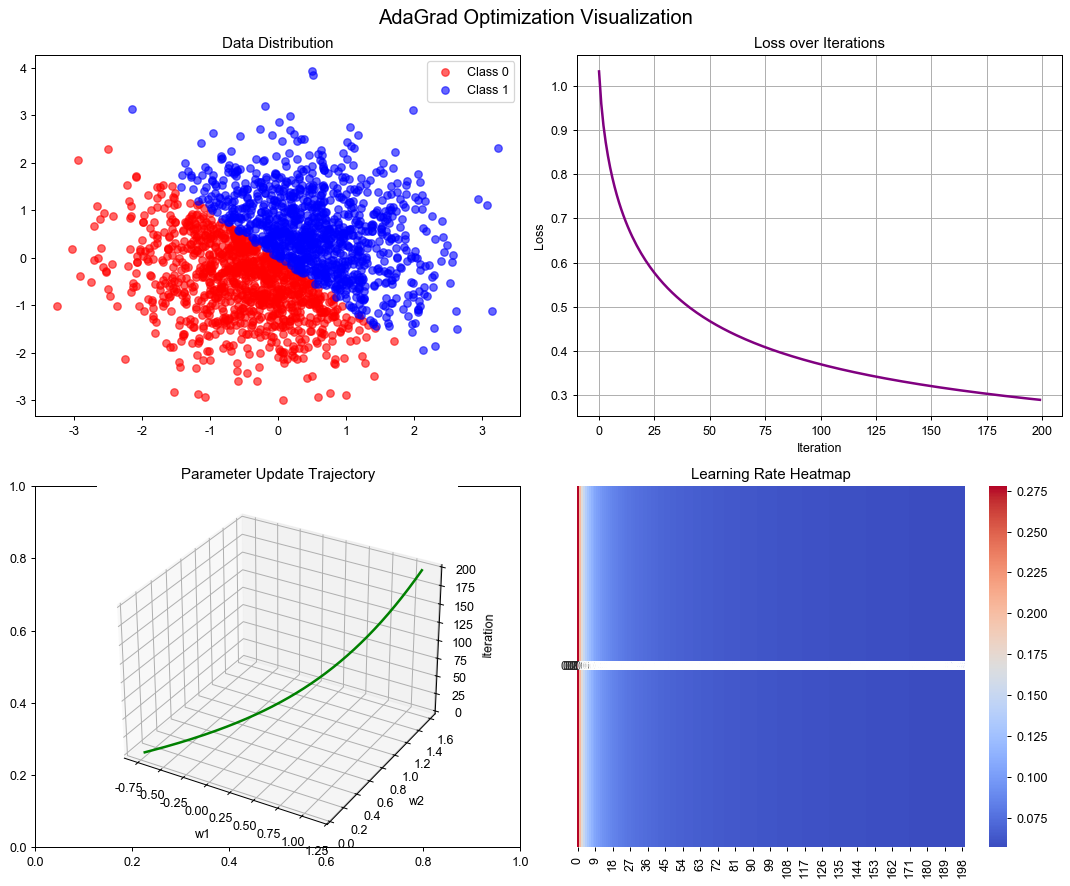

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 生成模拟数据
np.random.seed(42)
n_samples = 2000
X = np.random.randn(n_samples, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)  # y=1 if x1 + x2 > 0, else y=0

# 初始化参数
w = np.random.randn(2)
b = 0
alpha = 0.1  # 初始学习率
epsilon = 1e-8  # 避免除零错误
G_w = np.zeros(2)  # 梯度平方和
G_b = 0  # 偏置梯度平方和

# 存储训练过程数据
losses = []
w_updates = []
learning_rates = []


# Sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# 训练循环
for epoch in range(200):
    z = np.dot(X, w) + b
    predictions = sigmoid(z)

    # 计算损失
    loss = -np.mean(y * np.log(predictions + epsilon) + (1 - y) * np.log(1 - predictions + epsilon))
    losses.append(loss)

    # 计算梯度
    error = predictions - y
    grad_w = np.dot(X.T, error) / n_samples
    grad_b = np.mean(error)

    # 累积梯度平方
    G_w += grad_w ** 2
    G_b += grad_b ** 2

    # 计算自适应学习率
    adjusted_alpha_w = alpha / (np.sqrt(G_w) + epsilon)
    adjusted_alpha_b = alpha / (np.sqrt(G_b) + epsilon)
    learning_rates.append(adjusted_alpha_w.mean())

    # 更新参数
    w -= adjusted_alpha_w * grad_w
    b -= adjusted_alpha_b * grad_b

    # 记录参数轨迹
    w_updates.append(w.copy())

# 转换参数更新轨迹数据
w_updates = np.array(w_updates)

# 画图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("AdaGrad Optimization Visualization", fontsize=16, fontweight='bold')

# 1. 数据分布（散点图）
ax1 = axes[0, 0]
ax1.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0', alpha=0.6)
ax1.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
ax1.set_title("Data Distribution")
ax1.legend()

# 2. 损失值变化（折线图）
ax2 = axes[0, 1]
ax2.plot(losses, color='purple', linewidth=2)
ax2.set_title("Loss over Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Loss")
ax2.grid(True)

# 3. 参数更新轨迹（3D 轨迹图）
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot(w_updates[:, 0], w_updates[:, 1], np.arange(len(w_updates)), color='green', linewidth=2)
ax3.set_xlabel("w1")
ax3.set_ylabel("w2")
ax3.set_zlabel("Iteration")
ax3.set_title("Parameter Update Trajectory")

# 4. 学习率变化（热力图）
ax4 = axes[1, 1]
sns.heatmap(np.array([learning_rates]), cmap='coolwarm', cbar=True, ax=ax4, annot=True, fmt='.4f')
ax4.set_title("Learning Rate Heatmap")
ax4.set_yticks([])

plt.tight_layout()
plt.show()

- **数据生成**：创建 2000 个 2D 样本，并根据 $x_1 + x_2 > 0$ 进行二分类。
- **AdaGrad 训练**：

  - 计算梯度，并累积其平方值。
  - 计算自适应学习率，并更新参数。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

1. **数据分布**：分类散点图，展示数据结构。
2. **损失变化**：折线图展示损失如何收敛。
3. **参数更新轨迹**：3D 轨迹图，展示 $w_1, w_2$ 的变化过程。
4. **学习率变化**：热力图，展示学习率的变化趋势。

## 优缺点和适用场景

### AdaGrad 优点

1. **自适应学习率**：

   - 每个参数都有自己独立的学习率，不同参数的学习率会根据其梯度历史自动调整，而不是使用全局固定学习率。
   - 对于更新频繁的参数，学习率逐渐减小；对于较少更新的参数，学习率保持相对较大。
2. **适用于稀疏数据**：

   - 在自然语言处理（NLP）、推荐系统等任务中，很多特征是**稀疏的**（即大部分参数的梯度是 0，只有少部分参数有非零梯度）。
   - 由于 AdaGrad 会**增加稀疏参数的学习率**，使得这些参数能够更快地学习，从而提高模型的收敛速度。
3. **无需手动调整学习率衰减**：

   - 传统梯度下降需要人为设计学习率衰减策略，而 AdaGrad 通过自动调整学习率，无需额外设置。
4. **适用于凸优化问题**：

   - 在凸优化问题（如逻辑回归、线性回归等）中，AdaGrad 表现较好，并能较快收敛。

### AdaGrad 缺点

1. **学习率衰减过快**：

   - AdaGrad 的学习率更新方式：  
   $\alpha_t^{(j)} = \frac{\alpha}{\sqrt{G_t^{(j)} + \epsilon}}$
   - 由于 $G_t^{(j)}$是梯度平方和的累积值，随着训练时间的增加，**学习率会不断降低**，甚至趋近于 0，导致后期模型学习停滞。
2. **不适合深度学习**：

   - 深度神经网络通常需要更长时间的训练，而 AdaGrad 的学习率下降太快，导致训练到后期时几乎无法学习。
   - 在深度学习中，**RMSprop、Adam** 等改进算法更受欢迎。
3. **无法高效跳出局部最优**：

   - 由于学习率下降过快，AdaGrad **难以在非凸优化问题中跳出局部最优解**，从而影响最终的模型效果。

### 适合 AdaGrad 场景

1. **稀疏数据优化问题**

   - NLP（如文本分类、词向量训练）
   - 推荐系统（如协同过滤）
   - 计算机视觉中某些特征较少的任务
2. **凸优化问题**

   - 逻辑回归（Logistic Regression）
   - 线性回归（Linear Regression）
   - 支持向量机（SVM）
3. **小规模机器学习任务**

   - 适用于数据集较小、训练时间较短的任务，因为 AdaGrad 在初期收敛较快。

### 不适合 AdaGrad 场景

1. **深度学习任务**：由于学习率下降过快，深度神经网络（如 CNN、RNN）往往使用 RMSprop 或 Adam 来代替 AdaGrad。
2. **非凸优化问题**：例如训练 GAN（生成对抗网络）时，AdaGrad 可能会因学习率过小而陷入局部最优。

### 总结一下

| 特性 | AdaGrad |
|-|-|
| **自适应学习率** | ✅ 每个参数都有独立的学习率 |
| **适用于稀疏数据** | ✅ 适合 NLP、推荐系统等任务 |
| **适用于凸优化问题** | ✅ 线性回归、逻辑回归、SVM |
| **学习率衰减问题** | ❌ 下降太快，训练后期学习率趋近于 0 |
| **适用于深度学习** | ❌ 学习率过快降低，不适合 DNN |
| **适用于非凸优化问题** | ❌ 难以跳出局部最优 |
| **推荐替代方案** | RMSprop、Adam、Adadelta |

**结论**：AdaGrad 在 **稀疏数据、凸优化问题** 中非常有效，但在 **深度学习、大规模非凸优化问题** 中不适用，建议使用 **RMSprop、Adam 等改进方法**。